In [23]:
import os
import json
import pickle
import numpy as np
import cv2
from tqdm import tqdm
from PIL import Image

import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.ops import box_iou
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgba
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── Paths ──
DATA_ROOT  = "/kaggle/input/datasets/sudhirkh/deepfashion2/DeepFashion2"
TRAIN_PKL  = "/kaggle/input/datasets/sudhirkh/deepfashion-preprocessed/train_data.pkl"
VAL_PKL    = "/kaggle/input/datasets/sudhirkh/deepfashion-preprocessed-val/validation_data.pkl"
SAVE_PATH  = "/kaggle/working/maskrcnn_scratch.pth"

# ── Label mapping ──
TOP5_IDS = [1, 8, 7, 2, 9]
CAT_TO_IDX = {cat: i for i, cat in enumerate(TOP5_IDS)}
IDX_TO_NAME = {
    0: "background",
    1: "short_sleeve_top",
    2: "trousers",
    3: "shorts",
    4: "long_sleeve_top",
    5: "skirt",
}
NUM_CLASSES = 6

# ── Reproducibility ──
random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.benchmark = True

print("Setup done.")

Device: cuda
Setup done.


In [24]:
with open(TRAIN_PKL, "rb") as f:
    train_paths, _ = pickle.load(f)

with open(VAL_PKL, "rb") as f:
    val_paths, _ = pickle.load(f)

random.shuffle(train_paths)
random.shuffle(val_paths)

TRAIN_SIZE = 7500
VAL_SIZE   = 2500

train_paths = train_paths[:TRAIN_SIZE]
val_paths   = val_paths[:VAL_SIZE]

print(f"Train: {len(train_paths)}")
print(f"Val:   {len(val_paths)}")

Train: 7500
Val:   2500


In [25]:
def parse_annotation(json_path):
    with open(json_path) as f:
        data = json.load(f)

    boxes, labels, masks = [], [], []

    for key in data:
        if not key.startswith("item"):
            continue
        cid = data[key]["category_id"]
        if cid not in CAT_TO_IDX:
            continue
        x1, y1, x2, y2 = data[key]["bounding_box"]
        if x2 <= x1 or y2 <= y1:
            continue
        boxes.append([x1, y1, x2, y2])
        labels.append(CAT_TO_IDX[cid] + 1)
        masks.append(data[key]["segmentation"])

    return boxes, labels, masks


def polygons_to_mask(polygons, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)
    for poly in polygons:
        pts = np.array(poly).reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(mask, [pts], 1)
    return mask

In [26]:
class DetectionDataset(Dataset):
    def __init__(self, image_paths, json_folder):
        self.image_paths = image_paths
        self.json_folder = json_folder

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path  = self.image_paths[idx]
        json_name = os.path.basename(img_path).replace(".jpg", ".json")
        json_path = os.path.join(self.json_folder, json_name)

        boxes, labels, segmentations = parse_annotation(json_path)

        # Skip empty images
        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self.image_paths))

        image       = Image.open(img_path).convert("RGB")
        width, height = image.size

        masks = [polygons_to_mask(seg, height, width) for seg in segmentations]
        masks = torch.tensor(np.array(masks), dtype=torch.uint8)

        target = {
            "boxes" : torch.tensor(boxes,  dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "masks" : masks,
        }

        return F.to_tensor(image), target


def collate_fn(batch):
    return tuple(zip(*batch))

In [27]:
train_dataset = DetectionDataset(train_paths, DATA_ROOT + "/train/annos")
val_dataset   = DetectionDataset(val_paths,   DATA_ROOT + "/validation/annos")

train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=True,
    num_workers=4, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset, batch_size=4, shuffle=False,
    num_workers=4, collate_fn=collate_fn
)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

Train batches: 1875
Val   batches: 625


In [28]:
img, tgt = train_dataset[0]
print("Image shape:", img.shape)
print("Boxes:",       tgt["boxes"])
print("Labels:",      tgt["labels"])
print("Masks shape:", tgt["masks"].shape)

Image shape: torch.Size([3, 831, 468])
Boxes: tensor([[  0., 128., 467., 565.]])
Labels: tensor([5])
Masks shape: torch.Size([1, 831, 468])


In [29]:
# No pretrained weights at all
model = torchvision.models.detection.maskrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None,
    min_size=512,
    max_size=512
)

# Replace heads
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = \
    torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, NUM_CLASSES)

in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = \
    torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(in_features_mask, 256, NUM_CLASSES)

model = model.to(device)

# Adam works better for scratch training
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Drop lr at epoch 4 and 8
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.1)

print("Scratch model ready.")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Scratch model ready.
Parameters: 43,997,043


In [30]:
EPOCHS    = 10
best_loss = float("inf")

for epoch in range(EPOCHS):

    # ── Train ──
    model.train()
    total_loss = cls_loss = box_loss = mask_loss = obj_loss = rpn_loss = 0

    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss      = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        cls_loss   += loss_dict.get("loss_classifier",  torch.tensor(0.)).item()
        box_loss   += loss_dict.get("loss_box_reg",     torch.tensor(0.)).item()
        mask_loss  += loss_dict.get("loss_mask",        torch.tensor(0.)).item()
        obj_loss   += loss_dict.get("loss_objectness",  torch.tensor(0.)).item()
        rpn_loss   += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.)).item()

    n = len(train_loader)

    # ── Validate ──
    model.train()
    val_total = val_cls = val_box = val_mask = val_obj = val_rpn = 0

    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict  = model(images, targets)
            val_total += sum(loss_dict.values()).item()
            val_cls   += loss_dict.get("loss_classifier",  torch.tensor(0.)).item()
            val_box   += loss_dict.get("loss_box_reg",     torch.tensor(0.)).item()
            val_mask  += loss_dict.get("loss_mask",        torch.tensor(0.)).item()
            val_obj   += loss_dict.get("loss_objectness",  torch.tensor(0.)).item()
            val_rpn   += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.)).item()

    m = len(val_loader)

    scheduler.step()

    # ── Print ──
    print(f"\n{'='*65}")
    print(f"Epoch {epoch+1}/{EPOCHS}  |  LR: {scheduler.get_last_lr()[0]:.2e}")
    print(f"{'='*65}")
    print(f"{'Loss':<25} {'Train':>10} {'Val':>10} {'Diff':>10}")
    print(f"{'-'*65}")
    print(f"{'Total':<25} {total_loss/n:>10.4f} {val_total/m:>10.4f} {val_total/m - total_loss/n:>+10.4f}")
    print(f"{'Classifier':<25} {cls_loss/n:>10.4f} {val_cls/m:>10.4f} {val_cls/m - cls_loss/n:>+10.4f}")
    print(f"{'Box Reg':<25} {box_loss/n:>10.4f} {val_box/m:>10.4f} {val_box/m - box_loss/n:>+10.4f}")
    print(f"{'Mask':<25} {mask_loss/n:>10.4f} {val_mask/m:>10.4f} {val_mask/m - mask_loss/n:>+10.4f}")
    print(f"{'Objectness':<25} {obj_loss/n:>10.4f} {val_obj/m:>10.4f} {val_obj/m - obj_loss/n:>+10.4f}")
    print(f"{'RPN Box':<25} {rpn_loss/n:>10.4f} {val_rpn/m:>10.4f} {val_rpn/m - rpn_loss/n:>+10.4f}")
    print(f"{'-'*65}")

    if val_total/m - total_loss/n > 0.15:
        print("  ⚠️  Warning: possible overfitting")
    elif val_total/m < total_loss/n:
        print("  ✅ Val loss lower than train — generalizing well")
    else:
        print("  ℹ️  Val close to train — healthy")

    if val_total/m < best_loss:
        best_loss = val_total/m
        torch.save(model.state_dict(), SAVE_PATH)
        print("  💾 Best model saved!")

print(f"\nTraining complete. Best Val Loss: {best_loss:.4f}")

Epoch 1/10 [Val]: 100%|██████████| 625/625 [02:07<00:00,  4.89it/s]



Epoch 1/10  |  LR: 1.00e-04
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total                         0.9209     0.8472    -0.0737
Classifier                    0.1956     0.2159    +0.0203
Box Reg                       0.1746     0.1902    +0.0155
Mask                          0.5121     0.4117    -0.1004
Objectness                    0.0301     0.0214    -0.0086
RPN Box                       0.0085     0.0080    -0.0005
-----------------------------------------------------------------
  ✅ Val loss lower than train — generalizing well
  💾 Best model saved!


Epoch 2/10 [Val]: 100%|██████████| 625/625 [02:05<00:00,  4.97it/s]



Epoch 2/10  |  LR: 1.00e-04
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total                         0.7171     0.6841    -0.0331
Classifier                    0.1608     0.1574    -0.0034
Box Reg                       0.1591     0.1544    -0.0047
Mask                          0.3747     0.3507    -0.0240
Objectness                    0.0163     0.0153    -0.0010
RPN Box                       0.0063     0.0063    +0.0000
-----------------------------------------------------------------
  ✅ Val loss lower than train — generalizing well
  💾 Best model saved!


Epoch 3/10 [Val]: 100%|██████████| 625/625 [02:05<00:00,  4.99it/s]


...


Epoch 8/10  |  LR: 1.00e-06
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total                         0.3943     0.5027    +0.1084
Classifier                    0.0865     0.1117    +0.0253
Box Reg                       0.0984     0.1229    +0.0245
Mask                          0.2026     0.2554    +0.0528
Objectness                    0.0039     0.0088    +0.0049
RPN Box                       0.0029     0.0039    +0.0010
-----------------------------------------------------------------
  ℹ️  Val close to train — healthy
  💾 Best model saved!


Epoch 9/10 [Val]: 100%|██████████| 625/625 [02:09<00:00,  4.84it/s]



Epoch 9/10  |  LR: 1.00e-06
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total                         0.3690     0.5026    +0.1335
Classifier                    0.0798     0.1116    +0.0319
Box Reg                       0.0913     0.1221    +0.0309
Mask                          0.1919     0.2562    +0.0643
Objectness                    0.0034     0.0088    +0.0054
RPN Box                       0.0027     0.0039    +0.0011
-----------------------------------------------------------------
  ℹ️  Val close to train — healthy
  💾 Best model saved!


Epoch 10/10 [Val]: 100%|██████████| 625/625 [02:08<00:00,  4.85it/s]


Epoch 10/10  |  LR: 1.00e-06
Loss                           Train        Val       Diff
-----------------------------------------------------------------
Total                         0.3635     0.5064    +0.1428
Classifier                    0.0784     0.1127    +0.0343
Box Reg                       0.0898     0.1231    +0.0333
Mask                          0.1894     0.2576    +0.0683
Objectness                    0.0032     0.0090    +0.0057
RPN Box                       0.0027     0.0039    +0.0012
-----------------------------------------------------------------
  ℹ️  Val close to train — healthy

Training complete. Best Val Loss: 0.5026


In [34]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

DET_SCORE_THRESH = 0.5
IOU_THRESH       = 0.5
MASK_THRESH      = 0.5

tp_det  = {i: 0   for i in range(1, NUM_CLASSES)}
fp_det  = {i: 0   for i in range(1, NUM_CLASSES)}
fn_det  = {i: 0   for i in range(1, NUM_CLASSES)}

iou_sum  = {i: 0.0 for i in range(1, NUM_CLASSES)}
dice_sum = {i: 0.0 for i in range(1, NUM_CLASSES)}
seg_cnt  = {i: 0   for i in range(1, NUM_CLASSES)}

print("Evaluating...")
with torch.no_grad():
    for images, targets in tqdm(val_loader):
        images  = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            pred_boxes  = out["boxes"].cpu()
            pred_scores = out["scores"].cpu()
            pred_labels = out["labels"].cpu()
            pred_masks  = out["masks"].cpu()

            gt_boxes  = tgt["boxes"]
            gt_labels = tgt["labels"]
            gt_masks  = tgt["masks"]

            keep        = pred_scores >= DET_SCORE_THRESH
            pred_boxes  = pred_boxes[keep]
            pred_labels = pred_labels[keep]
            pred_masks  = pred_masks[keep]

            gt_matched  = torch.zeros(len(gt_boxes), dtype=torch.bool)
            gt_matched2 = torch.zeros(len(gt_boxes), dtype=torch.bool)

            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                iou_matrix = box_iou(pred_boxes, gt_boxes)

                for p_idx in range(len(pred_boxes)):
                    p_cls    = pred_labels[p_idx].item()
                    iou_row  = iou_matrix[p_idx].clone()
                    iou_row[gt_labels != p_cls] = 0

                    best_iou, best_j = iou_row.max(0)

                    # Detection
                    if best_iou >= IOU_THRESH and not gt_matched[best_j]:
                        tp_det[p_cls] = tp_det.get(p_cls, 0) + 1
                        gt_matched[best_j] = True
                    else:
                        fp_det[p_cls] = fp_det.get(p_cls, 0) + 1

                    # Segmentation
                    if best_iou >= IOU_THRESH and not gt_matched2[best_j]:
                        gt_matched2[best_j] = True
                        p_mask = (pred_masks[p_idx, 0] >= MASK_THRESH).numpy().astype(np.uint8)
                        g_mask = gt_masks[best_j].numpy().astype(np.uint8)

                        if p_mask.shape != g_mask.shape:
                            p_mask = cv2.resize(p_mask, (g_mask.shape[1], g_mask.shape[0]),
                                                interpolation=cv2.INTER_NEAREST)

                        inter     = np.logical_and(p_mask, g_mask).sum()
                        union     = np.logical_or(p_mask,  g_mask).sum()
                        iou_val   = inter / (union + 1e-6)
                        dice_val  = 2 * inter / (p_mask.sum() + g_mask.sum() + 1e-6)

                        iou_sum[p_cls]  += iou_val
                        dice_sum[p_cls] += dice_val
                        seg_cnt[p_cls]  += 1

            for g_idx in range(len(gt_boxes)):
                if not gt_matched[g_idx]:
                    fn_det[gt_labels[g_idx].item()] = \
                        fn_det.get(gt_labels[g_idx].item(), 0) + 1

print("Evaluation complete.")

Evaluating...


100%|██████████| 625/625 [02:30<00:00,  4.16it/s]

Evaluation complete.


In [35]:
print("=" * 70)
print("DETECTION RESULTS (IoU threshold = 0.5)")
print("=" * 70)
print(f"{'Class':<22} {'Precision':>10} {'Recall':>10} {'F1':>10} {'TP':>6} {'FP':>6} {'FN':>6}")
print("-" * 70)

macro_p, macro_r, macro_f1 = [], [], []

for cls_id in range(1, NUM_CLASSES):
    tp = tp_det[cls_id]
    fp = fp_det[cls_id]
    fn = fn_det[cls_id]
    p  = tp / (tp + fp + 1e-6)
    r  = tp / (tp + fn + 1e-6)
    f1 = 2 * p * r / (p + r + 1e-6)
    macro_p.append(p); macro_r.append(r); macro_f1.append(f1)
    print(f"  {IDX_TO_NAME[cls_id]:<20} {p:>10.4f} {r:>10.4f} {f1:>10.4f} {tp:>6} {fp:>6} {fn:>6}")

print("-" * 70)
print(f"  {'Macro Avg':<20} {np.mean(macro_p):>10.4f} {np.mean(macro_r):>10.4f} {np.mean(macro_f1):>10.4f}")

all_tp = sum(tp_det.values())
all_fp = sum(fp_det.values())
all_fn = sum(fn_det.values())
mp  = all_tp / (all_tp + all_fp + 1e-6)
mr  = all_tp / (all_tp + all_fn + 1e-6)
mf1 = 2 * mp * mr / (mp + mr + 1e-6)
print(f"  {'Micro Avg':<20} {mp:>10.4f} {mr:>10.4f} {mf1:>10.4f}")

print()
print("=" * 70)
print("SEGMENTATION RESULTS")
print("=" * 70)
print(f"{'Class':<22} {'mIoU':>10} {'Dice':>10} {'Instances':>10}")
print("-" * 70)

all_ious, all_dices = [], []
for cls_id in range(1, NUM_CLASSES):
    cnt  = seg_cnt[cls_id]
    miou = iou_sum[cls_id]  / cnt if cnt > 0 else 0.0
    dice = dice_sum[cls_id] / cnt if cnt > 0 else 0.0
    all_ious.append(miou); all_dices.append(dice)
    print(f"  {IDX_TO_NAME[cls_id]:<20} {miou:>10.4f} {dice:>10.4f} {cnt:>10}")

print("-" * 70)
print(f"  {'Macro Avg':<20} {np.mean(all_ious):>10.4f} {np.mean(all_dices):>10.4f}")
print("=" * 70)

DETECTION RESULTS (IoU threshold = 0.5)
Class                   Precision     Recall         F1     TP     FP     FN
----------------------------------------------------------------------
  short_sleeve_top         0.5948     0.8520     0.7006   1123    765    195
  trousers                 0.5949     0.8743     0.7080    890    606    128
  shorts                   0.4659     0.7016     0.5600    301    345    128
  long_sleeve_top          0.4418     0.6798     0.5356    448    566    211
  skirt                    0.5872     0.6584     0.6208    451    317    234
----------------------------------------------------------------------
  Macro Avg                0.5369     0.7532     0.6250
  Micro Avg                0.5528     0.7819     0.6477

SEGMENTATION RESULTS
Class                        mIoU       Dice  Instances
----------------------------------------------------------------------
  short_sleeve_top         0.8297     0.9030       1123
  trousers                 0.7786     0

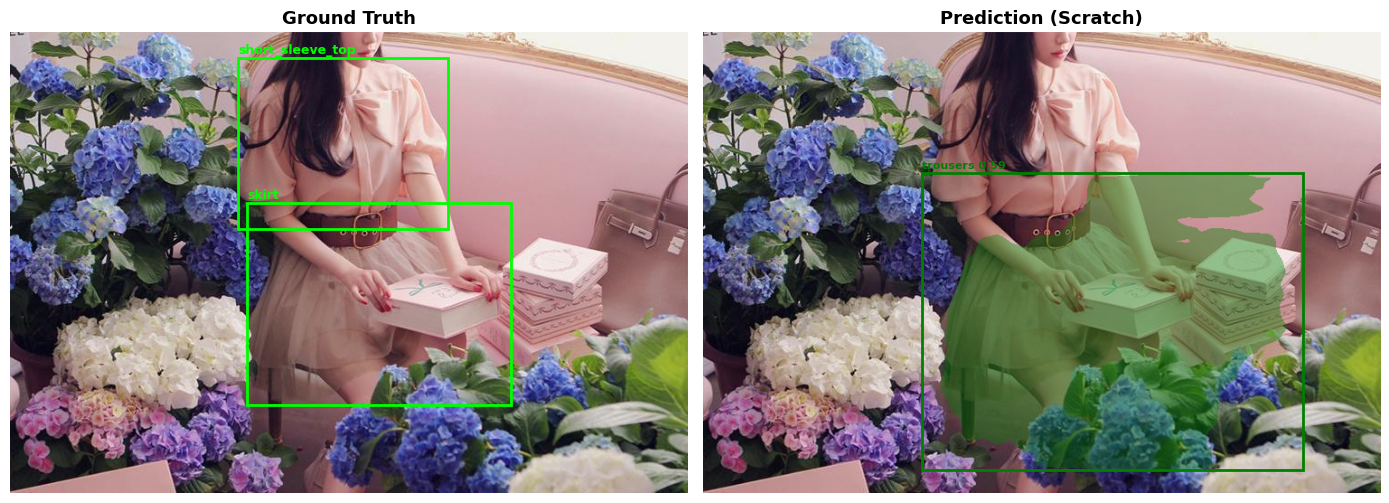

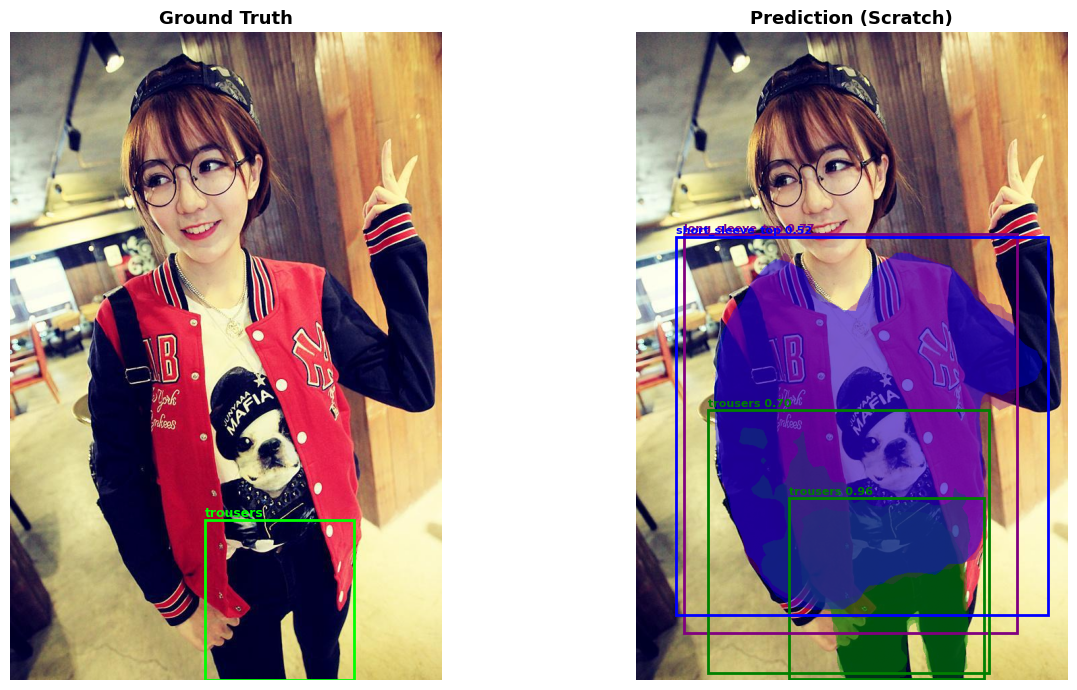

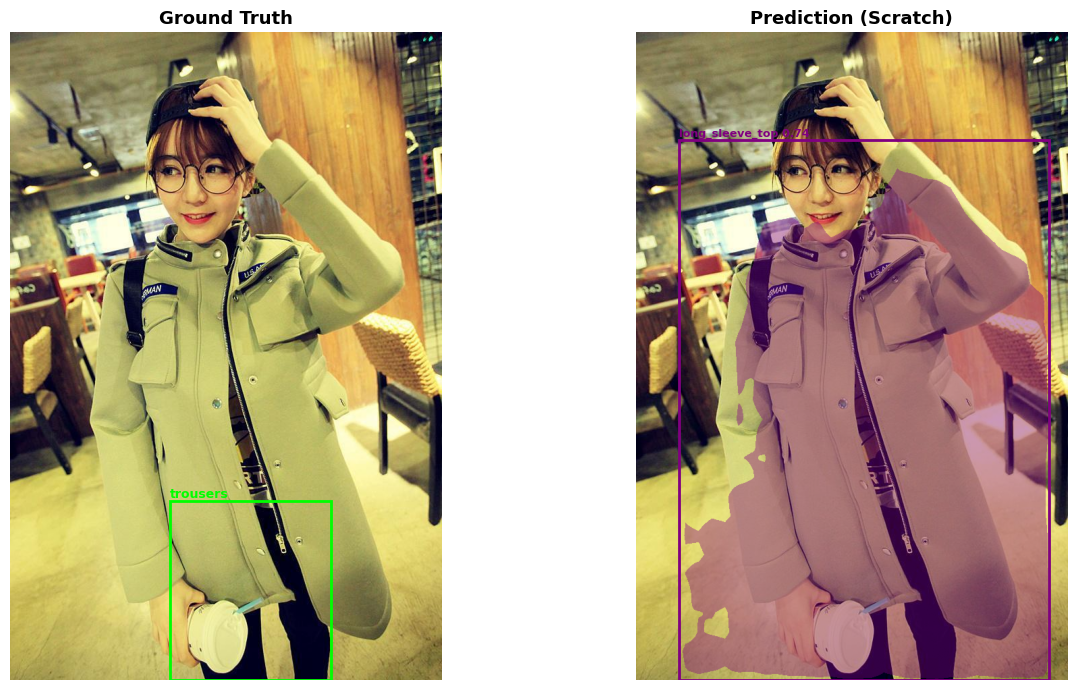

In [36]:
COLORS = ["red", "blue", "green", "orange", "purple"]

def visualize_prediction(model, dataset, idx=None, score_thresh=0.5):
    model.eval()
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)

    img_tensor, target = dataset[idx]
    image_np = img_tensor.permute(1, 2, 0).numpy()

    with torch.no_grad():
        output = model([img_tensor.to(device)])[0]

    pred_boxes  = output["boxes"].cpu().numpy()
    pred_scores = output["scores"].cpu().numpy()
    pred_labels = output["labels"].cpu().numpy()
    pred_masks  = output["masks"].cpu().numpy()

    keep        = pred_scores >= score_thresh
    pred_boxes  = pred_boxes[keep]
    pred_labels = pred_labels[keep]
    pred_masks  = pred_masks[keep]
    pred_scores = pred_scores[keep]

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Ground truth
    axes[0].imshow(image_np)
    axes[0].set_title("Ground Truth", fontsize=13, fontweight="bold")
    for box, lbl in zip(target["boxes"].numpy(), target["labels"].numpy()):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x1, y1 - 4, IDX_TO_NAME.get(lbl, str(lbl)),
                     color="lime", fontsize=9, fontweight="bold")
    axes[0].axis("off")

    # Predictions
    axes[1].imshow(image_np)
    axes[1].set_title("Prediction (Scratch)", fontsize=13, fontweight="bold")
    for box, lbl, score, mask in zip(pred_boxes, pred_labels, pred_scores, pred_masks):
        x1, y1, x2, y2 = box
        color = COLORS[lbl % len(COLORS)]
        rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor=color, facecolor="none")
        axes[1].add_patch(rect)
        axes[1].text(x1, y1 - 4,
                     f"{IDX_TO_NAME.get(lbl, str(lbl))} {score:.2f}",
                     color=color, fontsize=8, fontweight="bold")

        binary_mask = (mask[0] >= MASK_THRESH).astype(np.float32)
        rgba = np.zeros((*binary_mask.shape, 4))
        r, g, b, _ = to_rgba(color)
        rgba[..., 0] = r
        rgba[..., 1] = g
        rgba[..., 2] = b
        rgba[..., 3] = binary_mask * 0.4
        axes[1].imshow(rgba)

    axes[1].axis("off")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/viz_scratch_{idx}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Visualize 3 random samples
for _ in range(3):
    visualize_prediction(model, val_dataset, score_thresh=0.5)